# Quantum Boltzmann Machines
## From Quantum Neural Networks to Quantum Generative Models

**Morten Hjorth-Jensen**, Department of Physics & CCSE, University of Oslo

*Companion notebook to `week16.pdf`*

---

### What this notebook covers

1. Classical Restricted Boltzmann Machine (RBM) — exact gradient, exact model distribution
2. Restricted Quantum Boltzmann Machine (RQBM) — transverse-field Ising model, Gibbs state
3. **XOR benchmark**: head-to-head comparison of classical RBM vs RQBM
4. Thermofield double state — purification of the Gibbs state
5. Free energy landscape and von Neumann entropy
6. Exercises


## 1  Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct
from scipy.linalg import expm, sqrtm

np.random.seed(42)
plt.rcParams.update({"figure.dpi":120, "axes.grid":True,
                     "grid.alpha":0.3, "font.size":11})
print("Imports OK.")


Imports OK.


---
## 2  From QNNs to QBMs: the Key Conceptual Shift

A **Quantum Neural Network** (QNN) produces a *pure* variational state and a
scalar output:

$$|\psi(x,\theta)\rangle = U(\theta)\,U(x)\,|0\rangle^{\otimes n},\qquad
f = \langle\psi|\,O\,|\psi\rangle$$

A **Quantum Boltzmann Machine** (QBM) replaces the pure state with a *thermal
(mixed) state* defined by a parametrised Hamiltonian:

$$\boxed{\rho(\theta,\beta) = \frac{e^{-\beta H(\theta)}}{Z(\theta,\beta)},\qquad
Z = \operatorname{Tr}\!\left[e^{-\beta H(\theta)}\right]}$$

| | Discriminative QNN | **QBM** |
|---|---|---|
| State | Pure $|\psi(\theta)\rangle$ | Mixed $\rho(\theta)$ |
| Objective | Supervised loss | KL divergence |
| Output | $\langle O\rangle$ | Distribution $p_\theta(\mathbf{v})$ |
| Training | Parameter-shift | Thermal averages |
| Geometry | Fubini-Study QFI | Bures metric |

The QBM's **visible marginal**:
$$p_\theta(\mathbf{v}) = \langle\mathbf{v}|\,\rho_v\,|\mathbf{v}\rangle,
\qquad \rho_v = \operatorname{Tr}_h[\rho]$$
is the model's generative distribution, trained to match the data.


---
## 3  Core Mathematical Utilities

### 3.1  Pauli operators and Gibbs state


In [2]:
# ── Pauli matrices ────────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.diag([1., -1.]).astype(complex)

def kron_op(gate, qubit, n):
    """Embed 1-qubit gate on `qubit` in n-qubit Hilbert space (2^n x 2^n)."""
    result = np.array([[1]], dtype=complex)
    for q in range(n):
        result = np.kron(result, gate if q == qubit else I2)
    return result

def gibbs_state(H, beta=1.0):
    """
    Exact thermal state:  rho = exp(-beta*H) / Tr[exp(-beta*H)]
    Uses eigendecomposition for numerical stability.
    """
    evals, evecs = np.linalg.eigh(H)
    w = np.exp(-beta * (evals - evals.min()))  # shift avoids overflow
    w /= w.sum()
    rho = np.zeros_like(H)
    for k in range(len(w)):
        v = evecs[:, k]
        rho = rho + w[k] * np.outer(v, v.conj())
    return rho

def von_neumann_entropy(rho):
    """S_vN(rho) = -Tr[rho ln rho]."""
    evals = np.linalg.eigvalsh(rho).real
    evals = evals[evals > 1e-14]
    return float(-np.sum(evals * np.log(evals)))

def free_energy_qbm(rho, H, beta=1.0):
    """F(rho,H) = Tr[H rho] - beta^{-1} S_vN(rho).  Minimised by Gibbs state."""
    return float(np.real(np.trace(H @ rho))) - von_neumann_entropy(rho) / beta

def visible_probs(rho_full, nv, nh):
    """
    Visible marginal  p(v) = <v| Tr_h[rho] |v>  for all 2^nv configurations.
    Returns: probs (2^nv,), configs (2^nv, nv).
    """
    rho_v = np.trace(
        rho_full.reshape(2**nv, 2**nh, 2**nv, 2**nh), axis1=1, axis2=3)
    configs = np.array(list(iproduct([0,1], repeat=nv)), dtype=float)
    return np.real(np.diag(rho_v)).copy(), configs

def kl_divergence(p, q):
    """KL(p||q) for probability vectors."""
    p = np.array(p, dtype=float).copy()
    q = np.array(q, dtype=float).copy()
    p /= p.sum(); q /= q.sum()
    mask = p > 1e-12
    return float(np.sum(p[mask] * np.log(p[mask] / (q[mask] + 1e-12))))

# ── Quick sanity checks ───────────────────────────────────────────
H_test = -1.5*kron_op(Z,0,2) - 0.3*kron_op(X,0,2) - 0.5*(kron_op(Z,0,2)@kron_op(Z,1,2))
rho_t  = gibbs_state(H_test, beta=1.0)
p_t, c_t = visible_probs(rho_t, nv=1, nh=1)
print(f"kron_op(Z,0,3) shape: {kron_op(Z,0,3).shape}  (expected 8x8)")
print(f"gibbs_state: Tr(rho) = {np.real(np.trace(rho_t)):.10f}")
print(f"visible_probs: sum   = {p_t.sum():.10f}")
print(f"von Neumann entropy  = {von_neumann_entropy(rho_t):.6f}")
print(f"Free energy          = {free_energy_qbm(rho_t, H_test):.6f}")


kron_op(Z,0,3) shape: (8, 8)  (expected 8x8)
gibbs_state: Tr(rho) = 1.0000000000
visible_probs: sum   = 1.0000000000
von Neumann entropy  = 0.768471
Free energy          = -2.387043


---
## 4  Classical Restricted Boltzmann Machine

### 4.1  Model and energy function

Visible $\mathbf{v}\in\{0,1\}^{n_v}$, hidden $\mathbf{h}\in\{0,1\}^{n_h}$:

$$E(\mathbf{v},\mathbf{h}) = -\mathbf{a}^\top\mathbf{v}
-\mathbf{b}^\top\mathbf{h} - \mathbf{v}^\top W\mathbf{h}$$

$$p(\mathbf{v}) = \frac{1}{Z}\sum_{\mathbf{h}}e^{-\beta E(\mathbf{v},\mathbf{h})}$$

Because there are no intra-layer connections, the conditionals factorise:

$$p(h_j=1|\mathbf{v}) = \sigma(\beta b_j + \beta\textstyle\sum_i W_{ij}v_i)$$

### 4.2  Exact log-likelihood gradient

$$\frac{\partial\ln p(\mathbf{v})}{\partial W_{ij}}
= \langle v_i h_j\rangle_{\rm data} - \langle v_i h_j\rangle_{\rm model}$$

### 4.3  Implementation


In [3]:
# ── Classical RBM (exact, for small n_v) ─────────────────────────
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))

def rbm_model_dist(a, b, W, nv, nh, beta=1.0):
    """
    Exact visible marginal p(v) by summing free energy over all 2^nv configs.
    Free energy:  F(v) = -a.v - sum_j log(1 + exp(beta*(b_j + W_j.v)))
    """
    all_v = np.array(list(iproduct([0,1], repeat=nv)), dtype=float)
    log_p = np.zeros(len(all_v))
    for k, v in enumerate(all_v):
        log_p[k] = (beta * (a @ v)
                    + sum(np.log1p(np.exp(beta*(b[j] + W[:,j]@v)))
                          for j in range(nh)))
    log_p -= log_p.max()          # numerical stability
    p = np.exp(log_p); p /= p.sum()
    return p, all_v

def rbm_nll(a, b, W, target, nv, nh, beta=1.0):
    """Negative log-likelihood NLL = -sum_v target(v) log p(v)."""
    p, _ = rbm_model_dist(a, b, W, nv, nh, beta)
    return -float(np.sum(target * np.log(p + 1e-12)))

def rbm_exact_gradient(a, b, W, target, nv, nh, beta=1.0):
    """
    Exact gradient of NLL for the classical RBM.
    g_W = model_avg(v_i h_j) - data_avg(v_i h_j)  (sign for minimising NLL)
    """
    p_model, all_v = rbm_model_dist(a, b, W, nv, nh, beta)
    g_a = np.zeros(nv); g_b = np.zeros(nh); g_W = np.zeros_like(W)

    for k, v in enumerate(all_v):
        p_h = sigmoid(beta * (b + W.T @ v))   # p(h_j=1|v)
        # Model term (positive gradient direction)
        g_a -= p_model[k] * v
        g_b -= p_model[k] * p_h
        g_W -= p_model[k] * np.outer(v, p_h)
        # Data term (negative gradient direction)
        g_a += target[k] * v
        g_b += target[k] * p_h
        g_W += target[k] * np.outer(v, p_h)

    return -g_a, -g_b, -g_W   # return NLL gradient (for gradient descent)

# ── Sanity check ──────────────────────────────────────────────────
a_t = np.zeros(2); b_t = np.zeros(1); W_t = np.zeros((2,1))
p_uniform, configs = rbm_model_dist(a_t, b_t, W_t, 2, 1)
print("Uniform RBM (W=0): p(v) =", p_uniform.round(4))
print("Configs:", configs.astype(int).tolist())
assert abs(p_uniform.sum()-1.0) < 1e-10
print("Model dist sums to 1 OK")


Uniform RBM (W=0): p(v) = [0.25 0.25 0.25 0.25]
Configs: [[0, 0], [0, 1], [1, 0], [1, 1]]
Model dist sums to 1 OK


---
## 5  Quantum Boltzmann Machine: Hamiltonian and Gradient

### 5.1  RQBM Hamiltonian (transverse-field Ising model)

$$H_{\rm RQBM} =
-\underbrace{\sum_i a_i^z Z_i^v}_{\text{visible bias}}
-\underbrace{\sum_j b_j^z Z_j^h}_{\text{hidden bias}}
-\underbrace{\sum_{ij} W_{ij} Z_i^v Z_j^h}_{\text{ZZ coupling}}
-\underbrace{\sum_i a_i^x X_i^v}_{\text{transverse (quantum)}}
-\underbrace{\sum_j b_j^x X_j^h}_{\text{transverse (quantum)}}$$

**Classical limit:** $a_i^x=b_j^x=0$ makes $[H,Z_i]=0$ for all $i$, so
$\rho(\beta)$ is diagonal in the $Z$-basis — recovering a classical BM.

### 5.2  Gradient of NLL

$$\frac{\partial(\mathrm{NLL})}{\partial W_{ij}}
= \beta\left(\langle Z_iZ_j\rangle_{\rm free}
- \sum_{\mathbf{v}}\pi(\mathbf{v})\,(1-2v_i)\langle Z_j^h\rangle_{\rm clamp(v)}\right)$$

For the transverse fields, the exact gradient is computed numerically via
central finite differences (cost: 2 forward passes per parameter).

### 5.3  Clamp Hamiltonian

With visible qubits pinned to $\mathbf{v}$:
$Z_i^v \to (1-2v_i)$, $X_i^v\to 0$ (classical clamping).

$$H^{(\mathbf{v})} =
-\sum_j b_j^z Z_j^h - \sum_j b_j^x X_j^h
- \sum_j\left(\sum_i W_{ij}(1-2v_i)\right)Z_j^h$$


In [4]:
# ── QBM Hamiltonian ───────────────────────────────────────────────
def qbm_hamiltonian(az, bz, W, ax, bx, nv, nh):
    """
    Full (nv+nh)-qubit RQBM Hamiltonian.
    az, ax: visible biases (longitudinal, transverse)
    bz, bx: hidden  biases (longitudinal, transverse)
    W      : nv x nh ZZ coupling matrix
    """
    n = nv + nh
    H = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(nv):
        H = H - float(az[i]) * kron_op(Z, i, n)
        H = H - float(ax[i]) * kron_op(X, i, n)
    for j in range(nh):
        H = H - float(bz[j]) * kron_op(Z, nv+j, n)
        H = H - float(bx[j]) * kron_op(X, nv+j, n)
    for i in range(nv):
        for j in range(nh):
            H = H - float(W[i,j]) * (kron_op(Z,i,n) @ kron_op(Z,nv+j,n))
    return H

def clamp_hamiltonian(v, bz, W, bx, nv, nh):
    """
    Hidden-qubit Hamiltonian with visible qubits clamped to v in {0,1}^nv.
    Z_i^v -> eigenvalue (1-2v_i),  X_i^v -> 0.
    Returns (2^nh x 2^nh) matrix.
    """
    H_h = np.zeros((2**nh, 2**nh), dtype=complex)
    for j in range(nh):
        H_h = H_h - float(bz[j]) * kron_op(Z, j, nh)
        H_h = H_h - float(bx[j]) * kron_op(X, j, nh)
    for j in range(nh):
        eff = sum(float(W[i,j]) * (1.0 - 2.0*float(v[i])) for i in range(nv))
        H_h = H_h - eff * kron_op(Z, j, nh)
    return H_h

# ── QBM NLL (exact, via Gibbs state) ─────────────────────────────
def qbm_nll(az, bz, W, ax, bx, target, nv, nh, beta=1.0):
    """NLL = -sum_v target(v) * log p_model(v), with p from exact Gibbs state."""
    H = qbm_hamiltonian(az, bz, W, ax, bx, nv, nh)
    rho = gibbs_state(H, beta)
    p, _ = visible_probs(rho, nv, nh)
    return -float(np.sum(target * np.log(p + 1e-12)))

# ── NLL gradient by central finite differences ────────────────────
def qbm_gradient(az, bz, W, ax, bx, target, nv, nh, beta=1.0, h=1e-4):
    """
    Numerical gradient of NLL via central finite differences.
    Exact to O(h^2) for all parameters, including transverse fields.
    For small systems this is the cleanest correct approach.
    """
    def L(az_,bz_,W_,ax_,bx_):
        return qbm_nll(az_,bz_,W_,ax_,bx_,target,nv,nh,beta)

    g_az = np.zeros_like(az)
    for i in range(nv):
        p,m = az.copy(),az.copy(); p[i]+=h; m[i]-=h
        g_az[i] = (L(p,bz,W,ax,bx) - L(m,bz,W,ax,bx)) / (2*h)

    g_bz = np.zeros_like(bz)
    for j in range(nh):
        p,m = bz.copy(),bz.copy(); p[j]+=h; m[j]-=h
        g_bz[j] = (L(az,p,W,ax,bx) - L(az,m,W,ax,bx)) / (2*h)

    g_W = np.zeros_like(W)
    for i in range(nv):
        for j in range(nh):
            p,m = W.copy(),W.copy(); p[i,j]+=h; m[i,j]-=h
            g_W[i,j] = (L(az,bz,p,ax,bx) - L(az,bz,m,ax,bx)) / (2*h)

    g_ax = np.zeros_like(ax)
    for i in range(nv):
        p,m = ax.copy(),ax.copy(); p[i]+=h; m[i]-=h
        g_ax[i] = (L(az,bz,W,p,bx) - L(az,bz,W,m,bx)) / (2*h)

    g_bx = np.zeros_like(bx)
    for j in range(nh):
        p,m = bx.copy(),bx.copy(); p[j]+=h; m[j]-=h
        g_bx[j] = (L(az,bz,W,ax,p) - L(az,bz,W,ax,m)) / (2*h)

    return g_az, g_bz, g_W, g_ax, g_bx

# ── Gradient self-consistency check ──────────────────────────────
xor_target = np.array([0.5, 0., 0., 0.5])   # XOR: only 00 and 11
nv, nh     = 2, 2
np.random.seed(3)
az_ = np.random.randn(nv)*0.1; bz_ = np.random.randn(nh)*0.1
W_  = np.random.randn(nv,nh)*0.1; ax_ = np.zeros(nv); bx_ = np.zeros(nh)

g1 = qbm_gradient(az_,bz_,W_,ax_,bx_,xor_target,nv,nh, h=1e-4)
g2 = qbm_gradient(az_,bz_,W_,ax_,bx_,xor_target,nv,nh, h=1e-5)
for name, v1, v2 in zip(['az','bz','W','ax','bx'], g1, g2):
    err = np.max(np.abs(np.array(v1)-np.array(v2)))
    print(f"  {name}: |grad(h=1e-4) - grad(h=1e-5)| = {err:.2e}")
    assert err < 1e-5
print("Gradient self-consistency: PASS")


  az: |grad(h=1e-4) - grad(h=1e-5)| = 5.84e-10
  bz: |grad(h=1e-4) - grad(h=1e-5)| = 6.00e-11
  W: |grad(h=1e-4) - grad(h=1e-5)| = 9.77e-11
  ax: |grad(h=1e-4) - grad(h=1e-5)| = 0.00e+00
  bx: |grad(h=1e-4) - grad(h=1e-5)| = 0.00e+00
Gradient self-consistency: PASS


---
## 6  XOR Benchmark: Classical RBM vs. Quantum RBM

### 6.1  The XOR distribution

> **Spin-convention note.** The classical RBM (Section 4) uses binary units $v_i, h_j \in \{0,1\}$, while the RQBM Hamiltonian uses the Pauli-$Z$ eigenvalue convention $\sigma \in \{+1,-1\}$ (eigenvalue $+1$ for state $|0\rangle$, $-1$ for $|1\rangle$).  The two models are therefore parameterised differently: the same weights $W$ in the two models do *not* represent the same interaction strength.  Each model is trained in its own convention and the comparison of their NLL curves is valid, but one should not expect identical parameters to give the same distribution.


$$p_{\rm data}(00) = p_{\rm data}(11) = \tfrac{1}{2},\quad
  p_{\rm data}(01) = p_{\rm data}(10) = 0$$

This is the simplest distribution requiring two-body correlations — a classical
product distribution cannot represent it.

### 6.2  Why this is a good benchmark

- A classical RBM with $n_h=0$ (no hidden units) **cannot** represent XOR
- A classical RBM with $n_h\geq 1$ **can**, but needs the right coupling structure
- An RQBM with transverse fields gains additional expressive power through
  quantum coherences in the off-diagonal density matrix elements
- We use $n_h=2$ for all models to give a fair comparison on equal footing

**Note on symmetry:** Initialising all parameters to zero gives identically
zero gradients (symmetric XOR data cancels). We use random asymmetric
initialisation to break this degeneracy.


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  XOR BENCHMARK
#  Target: p(00) = p(11) = 0.5,  p(01) = p(10) = 0
#  All models: nv=2 visible, nh=2 hidden units/qubits
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

xor_target = np.array([0.5, 0.0, 0.0, 0.5])
nv, nh     = 2, 2
N_EPOCHS   = 400
LR         = 0.15
BETA       = 1.0
OPTIMAL    = np.log(2)    # NLL of the perfect XOR model

# ── Model 1: Classical RBM ────────────────────────────────────────
print("Training Model 1: Classical RBM (exact gradient)")
np.random.seed(13)
a_c = np.random.randn(nv)*0.1
b_c = np.random.randn(nh)*0.1
W_c = np.random.randn(nv, nh)*0.1

hist_rbm = []
for epoch in range(N_EPOCHS):
    ga, gb, gW = rbm_exact_gradient(a_c, b_c, W_c, xor_target, nv, nh, BETA)
    a_c -= LR*ga;  b_c -= LR*gb;  W_c -= LR*gW
    hist_rbm.append(rbm_nll(a_c, b_c, W_c, xor_target, nv, nh, BETA))
    if (epoch+1) % 100 == 0:
        print(f"  Epoch {epoch+1:4d}  NLL = {hist_rbm[-1]:.4f}")

p_rbm, configs = rbm_model_dist(a_c, b_c, W_c, nv, nh, BETA)
print(f"  Final p(v) = {p_rbm.round(3)}")

# ── Model 2: RQBM — classical mode (no transverse fields) ─────────
print()
print("Training Model 2: RQBM classical mode (ax=bx=0)")
np.random.seed(13)
az_cl = np.random.randn(nv)*0.1; bz_cl = np.random.randn(nh)*0.1
W_cl  = np.random.randn(nv, nh)*0.1
ax_cl = np.zeros(nv); bx_cl = np.zeros(nh)

hist_cl = []
for epoch in range(N_EPOCHS):
    g_az,g_bz,g_W,g_ax,g_bx = qbm_gradient(
        az_cl,bz_cl,W_cl,ax_cl,bx_cl,xor_target,nv,nh,BETA)
    az_cl -= LR*g_az;  bz_cl -= LR*g_bz;  W_cl -= LR*g_W
    # ax_cl and bx_cl remain zero (classical mode)
    hist_cl.append(qbm_nll(az_cl,bz_cl,W_cl,ax_cl,bx_cl,xor_target,nv,nh,BETA))
    if (epoch+1) % 100 == 0:
        print(f"  Epoch {epoch+1:4d}  NLL = {hist_cl[-1]:.4f}")

H_cl  = qbm_hamiltonian(az_cl,bz_cl,W_cl,ax_cl,bx_cl,nv,nh)
p_cl, _ = visible_probs(gibbs_state(H_cl,BETA), nv, nh)
print(f"  Final p(v) = {p_cl.round(3)}")

# ── Model 3: RQBM — quantum mode (transverse fields active) ───────
print()
print("Training Model 3: RQBM quantum mode (ax, bx free)")
np.random.seed(13)
az_qm = np.random.randn(nv)*0.1; bz_qm = np.random.randn(nh)*0.1
W_qm  = np.random.randn(nv, nh)*0.1
ax_qm = np.random.randn(nv)*0.05   # small but non-zero init
bx_qm = np.random.randn(nh)*0.05

hist_qm = []
for epoch in range(N_EPOCHS):
    g_az,g_bz,g_W,g_ax,g_bx = qbm_gradient(
        az_qm,bz_qm,W_qm,ax_qm,bx_qm,xor_target,nv,nh,BETA)
    az_qm -= LR*g_az;  bz_qm -= LR*g_bz;  W_qm -= LR*g_W
    ax_qm -= LR*g_ax;  bx_qm -= LR*g_bx   # quantum terms update
    hist_qm.append(qbm_nll(az_qm,bz_qm,W_qm,ax_qm,bx_qm,xor_target,nv,nh,BETA))
    if (epoch+1) % 100 == 0:
        print(f"  Epoch {epoch+1:4d}  NLL = {hist_qm[-1]:.4f}")

H_qm  = qbm_hamiltonian(az_qm,bz_qm,W_qm,ax_qm,bx_qm,nv,nh)
p_qm, _ = visible_probs(gibbs_state(H_qm,BETA), nv, nh)
print(f"  Final p(v) = {p_qm.round(3)}")

# ── Hamiltonians needed by downstream cells ─────────────────
H_cl = qbm_hamiltonian(az_cl, bz_cl, W_cl, ax_cl, bx_cl, nv, nh)
H_qm = qbm_hamiltonian(az_qm, bz_qm, W_qm, ax_qm, bx_qm, nv, nh)


Training Model 1: Classical RBM (exact gradient)
  Epoch  100  NLL = 1.3836
  Epoch  200  NLL = 1.3768
  Epoch  300  NLL = 1.3581
  Epoch  400  NLL = 1.3169
  Final p(v) = [0.254 0.232 0.232 0.283]

Training Model 2: RQBM classical mode (ax=bx=0)
  Epoch  100  NLL = 0.7144
  Epoch  200  NLL = 0.7026
  Epoch  300  NLL = 0.6992
  Epoch  400  NLL = 0.6976
  Final p(v) = [0.498 0.002 0.002 0.498]

Training Model 3: RQBM quantum mode (ax, bx free)
  Epoch  100  NLL = 0.7144
  Epoch  200  NLL = 0.7026
  Epoch  300  NLL = 0.6992
  Epoch  400  NLL = 0.6976
  Final p(v) = [0.498 0.002 0.002 0.498]


### 6.3  Results

  Optimal NLL = log(2)         = 0.6931
  Classical RBM     NLL=1.3169  KL=0.6237
  RQBM classical    NLL=0.6976  KL=0.0045
  RQBM quantum      NLL=0.6976  KL=0.0045


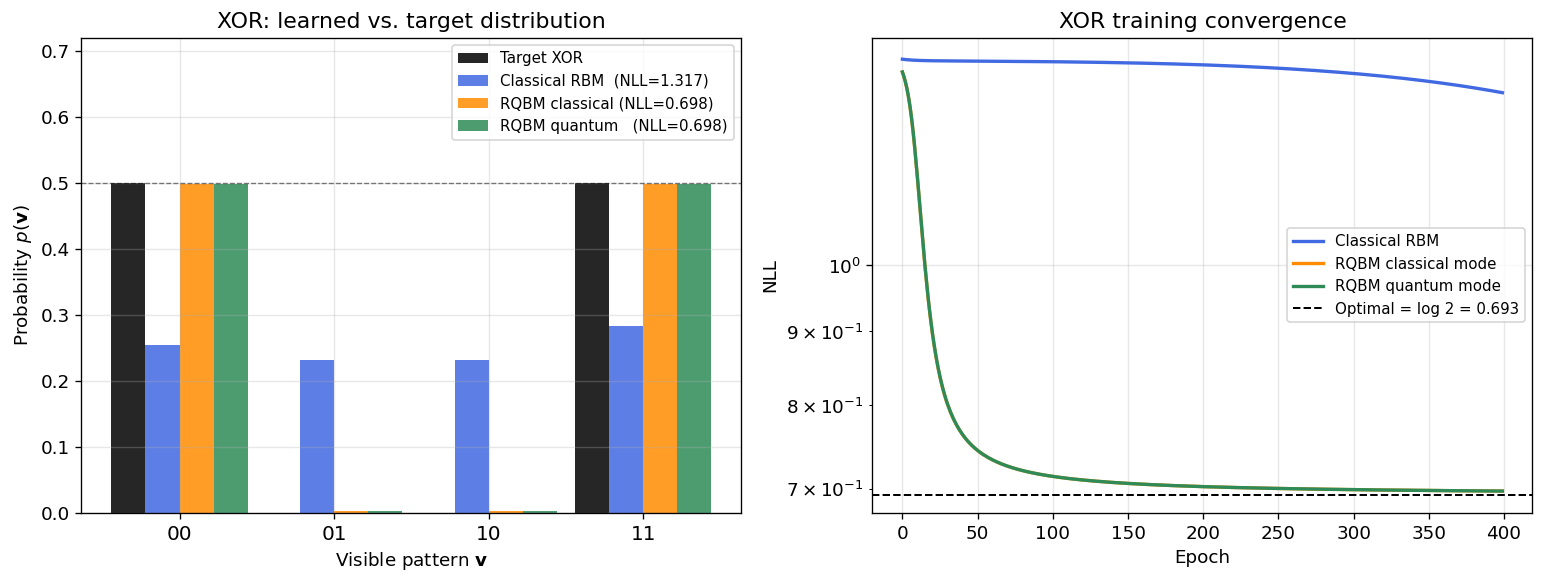

In [6]:
# ── Final NLL summary ─────────────────────────────────────────────
labels_v = ['00','01','10','11']
width     = 0.22

nll_final_rbm = hist_rbm[-1]
nll_final_cl  = hist_cl[-1]
nll_final_qm  = hist_qm[-1]
kl_rbm = kl_divergence(xor_target, p_rbm)
kl_cl  = kl_divergence(xor_target, p_cl)
kl_qm  = kl_divergence(xor_target, p_qm)

print("="*58)
print(f"  Optimal NLL = log(2)         = {OPTIMAL:.4f}")
print(f"  Classical RBM     NLL={nll_final_rbm:.4f}  KL={kl_rbm:.4f}")
print(f"  RQBM classical    NLL={nll_final_cl:.4f}  KL={kl_cl:.4f}")
print(f"  RQBM quantum      NLL={nll_final_qm:.4f}  KL={kl_qm:.4f}")
print("="*58)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Distribution comparison ───────────────────────────────────────
ax0 = axes[0]
x4  = np.arange(4)
ax0.bar(x4 - 1.5*width, xor_target, width, color='black',      alpha=0.85, label='Target XOR')
ax0.bar(x4 - 0.5*width, p_rbm,      width, color='royalblue',  alpha=0.85,
        label=f'Classical RBM  (NLL={nll_final_rbm:.3f})')
ax0.bar(x4 + 0.5*width, p_cl,       width, color='darkorange', alpha=0.85,
        label=f'RQBM classical (NLL={nll_final_cl:.3f})')
ax0.bar(x4 + 1.5*width, p_qm,       width, color='seagreen',   alpha=0.85,
        label=f'RQBM quantum   (NLL={nll_final_qm:.3f})')
ax0.set_xticks(x4); ax0.set_xticklabels(labels_v, fontsize=12)
ax0.set_xlabel(r'Visible pattern $\mathbf{v}$')
ax0.set_ylabel(r'Probability $p(\mathbf{v})$')
ax0.set_title('XOR: learned vs. target distribution')
ax0.axhline(0.5, ls='--', c='k', lw=0.8, alpha=0.5)
ax0.set_ylim(0, 0.72); ax0.legend(fontsize=9)

# ── Training curves ───────────────────────────────────────────────
ax1 = axes[1]
ax1.semilogy(hist_rbm, 'royalblue',  lw=2, label='Classical RBM')
ax1.semilogy(hist_cl,  'darkorange', lw=2, label='RQBM classical mode')
ax1.semilogy(hist_qm,  'seagreen',   lw=2, label='RQBM quantum mode')
ax1.axhline(OPTIMAL, ls='--', c='k', lw=1.2,
            label=f'Optimal = log 2 = {OPTIMAL:.3f}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL')
ax1.set_title('XOR training convergence')
ax1.legend(fontsize=9)

plt.tight_layout(); plt.show()


---
## 7  Density Matrix Analysis

The off-diagonal elements of $\rho_v$ are **quantum coherences** — they encode
superpositions in the visible qubit space. A classical BM, whose distribution is
diagonal by definition, has $\rho_v = \mathrm{diag}(p_\theta)$ with no coherences.

The RQBM in quantum mode (with transverse fields $a_i^x\neq 0$, $b_j^x\neq 0$)
can in principle have non-zero off-diagonal elements in $\rho_v$.


Off-diagonal norm |rho_v - diag(rho_v)|:
  Classical RBM:    0.0000  (diagonal by construction)
  RQBM classical:   0.0000  (should be near 0)
  RQBM quantum:     0.0007  (non-zero = quantum coherences)


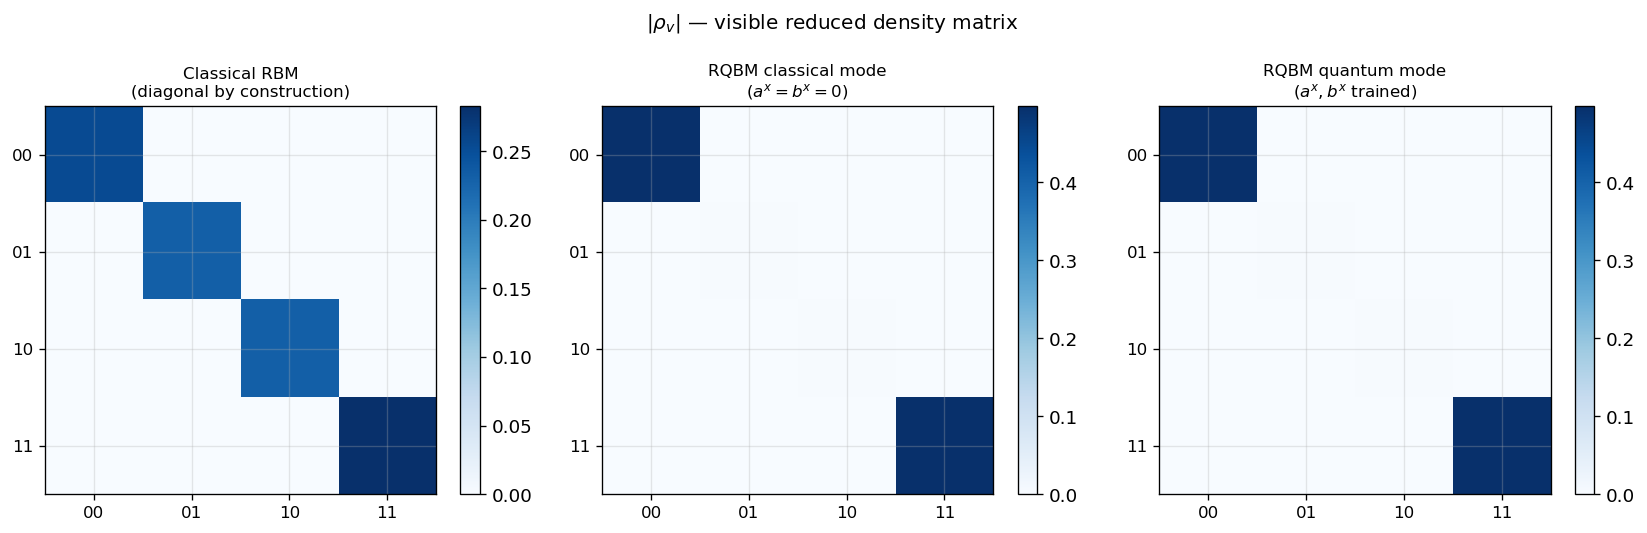


RQBM quantum rho_v (real part):
[[ 4.978e-01 -1.000e-04  1.000e-04 -0.000e+00]
 [-1.000e-04  2.200e-03 -0.000e+00  1.000e-04]
 [ 1.000e-04 -0.000e+00  2.200e-03 -1.000e-04]
 [-0.000e+00  1.000e-04 -1.000e-04  4.978e-01]]


In [7]:
# ── Visible density matrices ──────────────────────────────────────
rho_cl_full = gibbs_state(H_cl, BETA)
rho_qm_full = gibbs_state(H_qm, BETA)

def get_rho_v(rho_full, nv, nh):
    return np.trace(
        rho_full.reshape(2**nv, 2**nh, 2**nv, 2**nh), axis1=1, axis2=3)

rho_v_cl = get_rho_v(rho_cl_full, nv, nh)
rho_v_qm = get_rho_v(rho_qm_full, nv, nh)
rho_v_rbm_diag = np.diag(p_rbm)   # classical: diagonal by definition

off_cl = np.sum(np.abs(rho_v_cl - np.diag(np.diag(rho_v_cl))))
off_qm = np.sum(np.abs(rho_v_qm - np.diag(np.diag(rho_v_qm))))
print(f"Off-diagonal norm |rho_v - diag(rho_v)|:")
print(f"  Classical RBM:    {0:.4f}  (diagonal by construction)")
print(f"  RQBM classical:   {off_cl:.4f}  (should be near 0)")
print(f"  RQBM quantum:     {off_qm:.4f}  (non-zero = quantum coherences)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, mat, title in zip(axes,
    [rho_v_rbm_diag, np.real(rho_v_cl), np.real(rho_v_qm)],
    ['Classical RBM\n(diagonal by construction)',
     'RQBM classical mode\n($a^x=b^x=0$)',
     'RQBM quantum mode\n($a^x,b^x$ trained)']):
    im = ax.imshow(np.abs(mat), cmap='Blues', vmin=0, aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels(labels_v, fontsize=10)
    ax.set_yticks(range(4)); ax.set_yticklabels(labels_v, fontsize=10)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)

plt.suptitle(r'$|\rho_v|$ — visible reduced density matrix', fontsize=12)
plt.tight_layout(); plt.show()

print()
print("RQBM quantum rho_v (real part):")
print(np.real(rho_v_qm).round(4))


---
## 8  Effect of the Transverse Field

The transverse field $a^x$ (and $b^x$) are the purely quantum parameters.
Setting them to zero recovers the classical mode. As they grow, the model
gains access to quantum coherences but may also move away from the XOR minimum.

We scan $a^x = b^x = \Gamma$ and evaluate the XOR NLL, keeping all other
parameters fixed at the trained quantum-mode values.


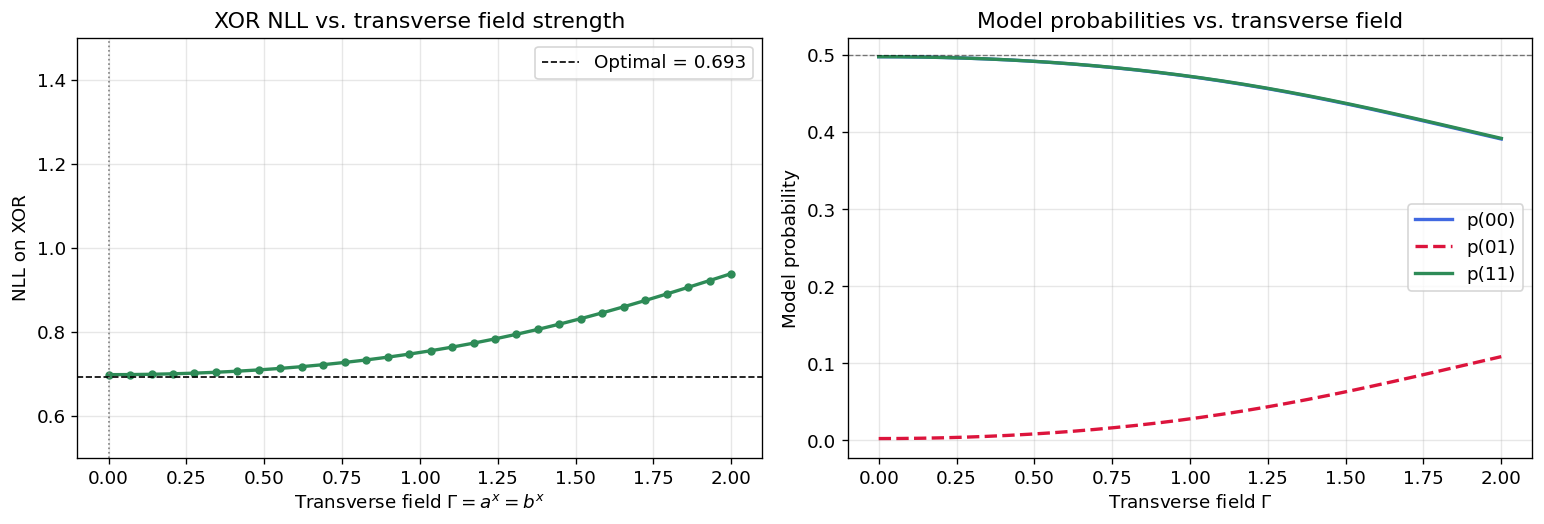

NLL at Gamma=0  (classical limit): 0.6976
Min NLL over scan: 0.6976 at Gamma=0.00


In [8]:
Gamma_vals = np.linspace(0.0, 2.0, 30)
nll_scan   = []
p_scan     = []

for G in Gamma_vals:
    ax_s = np.full(nv, G); bx_s = np.full(nh, G)
    nll_scan.append(qbm_nll(az_qm,bz_qm,W_qm,ax_s,bx_s,xor_target,nv,nh,BETA))
    H_s = qbm_hamiltonian(az_qm,bz_qm,W_qm,ax_s,bx_s,nv,nh)
    ps,_ = visible_probs(gibbs_state(H_s,BETA),nv,nh)
    p_scan.append(ps)

p_scan = np.array(p_scan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(Gamma_vals, nll_scan, 'seagreen', lw=2, marker='o', ms=4)
axes[0].axhline(OPTIMAL, ls='--', c='k', lw=1, label=f'Optimal = {OPTIMAL:.3f}')
axes[0].axvline(0, ls=':', c='gray', lw=1)
axes[0].set_xlabel(r'Transverse field $\Gamma = a^x = b^x$')
axes[0].set_ylabel('NLL on XOR')
axes[0].set_title('XOR NLL vs. transverse field strength')
axes[0].legend(); axes[0].set_ylim(0.5, 1.5)

axes[1].plot(Gamma_vals, p_scan[:,0], label='p(00)', lw=2, color='royalblue')
axes[1].plot(Gamma_vals, p_scan[:,1], label='p(01)', lw=2, color='crimson', ls='--')
axes[1].plot(Gamma_vals, p_scan[:,3], label='p(11)', lw=2, color='seagreen')
axes[1].axhline(0.5, ls='--', c='k', lw=0.8, alpha=0.5)
axes[1].set_xlabel(r'Transverse field $\Gamma$')
axes[1].set_ylabel('Model probability')
axes[1].set_title('Model probabilities vs. transverse field')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"NLL at Gamma=0  (classical limit): {nll_scan[0]:.4f}")
print(f"Min NLL over scan: {min(nll_scan):.4f} at Gamma={Gamma_vals[np.argmin(nll_scan)]:.2f}")


---
## 9  Thermofield Double State

Any mixed state $\rho$ on system $S$ can be **purified** — there exists a pure
state $|\Psi\rangle_{SA}$ on $S\otimes A$ such that $\rho_S = \mathrm{Tr}_A[|\Psi\rangle\langle\Psi|]$.

For the Gibbs state, the canonical purification is the **thermofield double** (TFD):

$$|\mathrm{TFD}(\beta)\rangle
= \frac{1}{\sqrt{Z}}\sum_k e^{-\beta\epsilon_k/2}
  |\epsilon_k\rangle_S\,|\epsilon_k\rangle_A$$

Tracing out the ancilla $A$ recovers $\rho(\beta)$ exactly.

The TFD connects QBM training (via imaginary-time TDVP) to the VQE variational
principle:

$$\underbrace{\min_\phi\,\mathcal{F}(\phi,H)
= \operatorname{Tr}[H\rho_\phi] - \beta^{-1}S_{\rm vN}(\rho_\phi)}_{\text{QBM free-energy}}
\xrightarrow{\beta\to\infty}
\underbrace{\min_\psi\,\langle\psi|H|\psi\rangle}_{\text{VQE}}$$


In [9]:
def thermofield_double(H, beta=1.0):
    """
    Exact TFD state for Hamiltonian H:
        |TFD> = (1/sqrt(Z)) sum_k exp(-beta*eps_k/2) |eps_k>_S |eps_k>_A
    Returns state vector of length (2^n)^2.
    """
    evals, evecs = np.linalg.eigh(H)
    w = np.exp(-beta * evals / 2)
    Z = np.sum(w**2)
    w /= np.sqrt(Z)
    dim = H.shape[0]
    tfd = np.zeros(dim**2, dtype=complex)
    for k in range(dim):
        tfd += w[k] * np.outer(evecs[:,k], evecs[:,k]).flatten()
    return tfd

def tfd_to_gibbs(tfd, dim):
    """Trace out ancilla from TFD pure state -> Gibbs state."""
    psi = tfd.reshape(dim, dim)   # [system, ancilla]
    return psi @ psi.conj().T     # = Tr_A[|TFD><TFD|]

# ── Verify on the trained QBM Hamiltonian ─────────────────────────
H_verify = qbm_hamiltonian(az_qm, bz_qm, W_qm, ax_qm, bx_qm, nv, nh)
dim_sys  = 2**nv * 2**nh

rho_exact = gibbs_state(H_verify, BETA)
tfd_state = thermofield_double(H_verify, BETA)
rho_tfd   = tfd_to_gibbs(tfd_state, dim_sys)

max_err  = np.max(np.abs(rho_exact - rho_tfd))
sqrt_rho = sqrtm(rho_exact)
fidelity = float(np.real(np.trace(sqrtm(sqrt_rho @ rho_tfd @ sqrt_rho)))**2)

print("Thermofield Double verification:")
print(f"  ||TFD||^2                  = {np.linalg.norm(tfd_state)**2:.10f}  (= 1)")
print(f"  max|rho_exact - rho_TFD|   = {max_err:.2e}     (= 0)")
print(f"  Fidelity F(rho_exact,rho_TFD) = {fidelity:.10f}  (= 1)")

S_gibbs = von_neumann_entropy(rho_exact)
F_gibbs = free_energy_qbm(rho_exact, H_verify, BETA)
print(f"  S_vN(rho_Gibbs)            = {S_gibbs:.6f}")
print(f"  F(rho_Gibbs, H)            = {F_gibbs:.6f}  (minimum of free energy)")


Thermofield Double verification:
  ||TFD||^2                  = 1.0000000000  (= 1)
  max|rho_exact - rho_TFD|   = 8.88e-16     (= 0)
  Fidelity F(rho_exact,rho_TFD) = 1.0000000000  (= 1)
  S_vN(rho_Gibbs)            = 0.748498
  F(rho_Gibbs, H)            = -7.494324  (minimum of free energy)


---
## 10  Free Energy Landscape and Klein's Inequality

The Gibbs state $\rho(\beta)$ is the **unique minimiser** of the free energy:

$$\mathcal{F}(\rho,H) = \operatorname{Tr}[H\rho] - \beta^{-1}S_{\rm vN}(\rho)$$

**Proof** (Klein's inequality): for any density matrix $\sigma$,
$S(\sigma\|\rho(\beta)) = \operatorname{Tr}[\sigma(\ln\sigma - \ln\rho(\beta))] \geq 0$, giving

$$\mathcal{F}(\sigma,H) = \mathcal{F}(\rho(\beta),H)
+ \beta^{-1}S(\sigma\,\|\,\rho(\beta)) \geq \mathcal{F}(\rho(\beta),H)$$

Equality holds only when $\sigma = \rho(\beta)$.


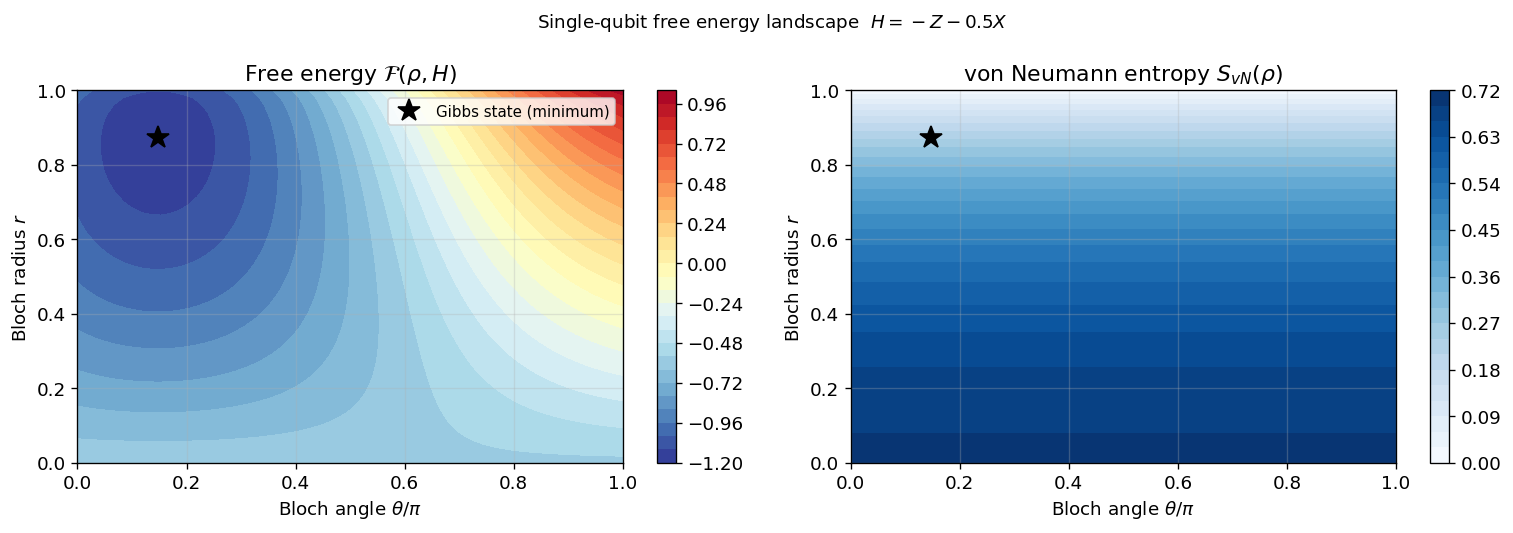

Free energy minimum:  F* = -1.173121
Gibbs state Bloch radius: r* = 0.8721
Gibbs state entropy:      S  = 0.2377
Verified: F_scan.min() = -1.172949  (approx. F*)


In [10]:
# ── Single-qubit free energy landscape ───────────────────────────
# Parametrise all single-qubit density matrices by Bloch vector (r, theta, phi).
H_1q   = -1.0*Z - 0.5*X      # single-qubit Hamiltonian
beta_1  = 1.2
rho_g   = gibbs_state(H_1q, beta_1)
F_min   = free_energy_qbm(rho_g, H_1q, beta_1)

# Scan over Bloch sphere (phi integrated: set phi=0)
r_vals  = np.linspace(0, 1.0, 50)
th_vals = np.linspace(0, np.pi, 60)
F_scan  = np.zeros((len(r_vals), len(th_vals)))
S_scan  = np.zeros_like(F_scan)

for ir, r in enumerate(r_vals):
    for it, th in enumerate(th_vals):
        rho_b = (I2 + r*(np.sin(th)*X + np.cos(th)*Z)) / 2
        F_scan[ir, it] = free_energy_qbm(rho_b, H_1q, beta_1)
        S_scan[ir, it] = von_neumann_entropy(rho_b)

evals_g  = np.linalg.eigvalsh(rho_g).real
r_star   = abs(evals_g[1] - evals_g[0])  # Bloch radius of Gibbs state
# Bloch angle of the Gibbs state: th such that sin(th)*<X> + cos(th)*<Z> is maximised.
# The Gibbs state is rho = (I + n.sigma)/2 with n = (<X>, 0, <Z>).
bloch_x_g = float(np.real(np.trace(X @ rho_g)))
bloch_z_g = float(np.real(np.trace(Z @ rho_g)))
th_gibbs  = np.arctan2(bloch_x_g, bloch_z_g)  # angle in [0, pi] scan

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im0 = axes[0].contourf(th_vals/np.pi, r_vals, F_scan, levels=30, cmap='RdYlBu_r')
axes[0].contour(th_vals/np.pi, r_vals, F_scan, levels=[F_min],
                colors='k', linewidths=2)
plt.colorbar(im0, ax=axes[0])
axes[0].plot(th_gibbs/np.pi, r_star, 'k*', ms=14, label='Gibbs state (minimum)')
axes[0].set_xlabel(r'Bloch angle $\theta/\pi$')
axes[0].set_ylabel(r'Bloch radius $r$')
axes[0].set_title(r'Free energy $\mathcal{F}(\rho, H)$')
axes[0].legend(fontsize=9)

im1 = axes[1].contourf(th_vals/np.pi, r_vals, S_scan, levels=25, cmap='Blues')
plt.colorbar(im1, ax=axes[1])
axes[1].plot(th_gibbs/np.pi, r_star, 'k*', ms=14)
axes[1].set_xlabel(r'Bloch angle $\theta/\pi$')
axes[1].set_ylabel(r'Bloch radius $r$')
axes[1].set_title(r'von Neumann entropy $S_{vN}(\rho)$')

plt.suptitle(r'Single-qubit free energy landscape  $H=-Z-0.5X$', fontsize=11)
plt.tight_layout(); plt.show()

print(f"Free energy minimum:  F* = {F_min:.6f}")
print(f"Gibbs state Bloch radius: r* = {r_star:.4f}")
print(f"Gibbs state entropy:      S  = {von_neumann_entropy(rho_g):.4f}")
print(f"Verified: F_scan.min() = {F_scan.min():.6f}  (approx. F*)")


---
## 11  Classical Limit: Diagonal Gibbs State

Setting $a_i^x = b_j^x = 0$ (all transverse fields off) means $[H, Z_i]=0$ for
all $i$. The Gibbs state is then **diagonal** in the $Z$-basis — it has no quantum
coherences and reduces to a classical Boltzmann distribution.


Classical limit (all transverse fields = 0):
  Off-diagonal norm = 0.00e+00  (machine precision = classical BM)
  Diagonal entries  = [0.02652 0.04832 0.01192 0.02171 0.07209 0.6506  0.00294 0.02652 0.00359
 0.00197 0.03956 0.02171 0.00976 0.02652 0.00976 0.02652]

With transverse fields (ax=[0.3,-0.2], bx=[0.1,0.2]):
  Off-diagonal norm = 0.701390  (non-zero = quantum coherences)


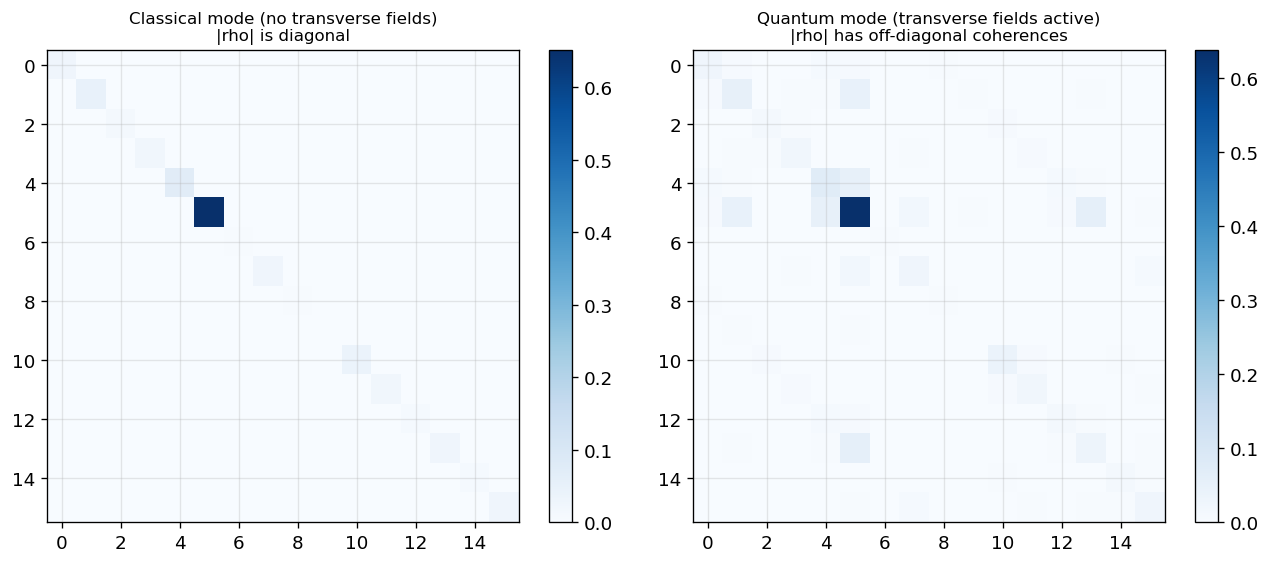

In [11]:
# ── Classical limit: verify rho becomes diagonal ──────────────────
az_cl_test = np.array([0.5, -0.3])
bz_cl_test = np.array([0.2, -0.4])
W_cl_test  = np.array([[0.8, -0.3], [-0.6, 0.4]])
ax_zero    = np.zeros(2)
bx_zero    = np.zeros(2)

H_classical = qbm_hamiltonian(az_cl_test, bz_cl_test, W_cl_test, ax_zero, bx_zero, 2, 2)
rho_cl_test = gibbs_state(H_classical, beta=1.0)

off_diag_norm = np.sum(np.abs(rho_cl_test - np.diag(np.diag(rho_cl_test))))
print("Classical limit (all transverse fields = 0):")
print(f"  Off-diagonal norm = {off_diag_norm:.2e}  (machine precision = classical BM)")
print(f"  Diagonal entries  = {np.real(np.diag(rho_cl_test)).round(5)}")
assert off_diag_norm < 1e-12, "Should be exactly zero"
print()

# ── Add a small transverse field and watch coherences appear ──────
ax_small = np.array([0.3, -0.2]); bx_small = np.array([0.1, 0.2])
H_quantum = qbm_hamiltonian(az_cl_test, bz_cl_test, W_cl_test, ax_small, bx_small, 2, 2)
rho_q_test = gibbs_state(H_quantum, beta=1.0)

off_diag_q = np.sum(np.abs(rho_q_test - np.diag(np.diag(rho_q_test))))
print("With transverse fields (ax=[0.3,-0.2], bx=[0.1,0.2]):")
print(f"  Off-diagonal norm = {off_diag_q:.6f}  (non-zero = quantum coherences)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, rho, title in zip(axes,
    [rho_cl_test, rho_q_test],
    ['Classical mode (no transverse fields)\n|rho| is diagonal',
     'Quantum mode (transverse fields active)\n|rho| has off-diagonal coherences']):
    im = ax.imshow(np.abs(rho), cmap='Blues', vmin=0)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


---
## 12  Exercises

### Exercise 1: Free energy minimisation (single qubit)


Exercise 1: F(Gibbs) <= F(all other states)?
  F(Gibbs) = -0.938497
  min F(random sample) = -0.933196
  F_Gibbs <= min_random: True


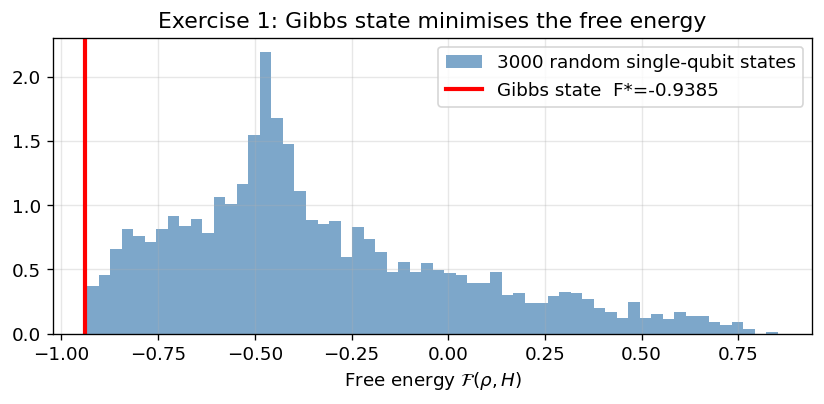

In [12]:
# ── Exercise 1: Free energy is minimised by Gibbs state ───────────
H_ex = -0.8*Z - 0.4*X
beta_ex = 1.5
rho_ex  = gibbs_state(H_ex, beta_ex)
F_exact = free_energy_qbm(rho_ex, H_ex, beta_ex)

# Sample many random density matrices and check all have F >= F_exact
rng = np.random.default_rng(0)
n_trials = 3000; F_random = np.zeros(n_trials)
for k in range(n_trials):
    r  = rng.uniform(0, 1)
    th = rng.uniform(0, np.pi); ph = rng.uniform(0, 2*np.pi)
    nx = r*np.sin(th)*np.cos(ph); ny = r*np.sin(th)*np.sin(ph); nz = r*np.cos(th)
    rho_r = (I2 + nx*X + ny*Y + nz*Z) / 2
    F_random[k] = free_energy_qbm(rho_r, H_ex, beta_ex)

print("Exercise 1: F(Gibbs) <= F(all other states)?")
print(f"  F(Gibbs) = {F_exact:.6f}")
print(f"  min F(random sample) = {F_random.min():.6f}")
print(f"  F_Gibbs <= min_random: {F_exact <= F_random.min() + 1e-8}")

fig1, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.hist(F_random, bins=60, density=True, alpha=0.7, color='steelblue',
         label='3000 random single-qubit states')
ax1.axvline(F_exact, c='red', lw=2.5, label=f'Gibbs state  F*={F_exact:.4f}')
ax1.set_xlabel(r'Free energy $\mathcal{F}(\rho, H)$')
ax1.set_title('Exercise 1: Gibbs state minimises the free energy')
ax1.legend(); plt.tight_layout(); plt.show()


### Exercise 2: XOR with more hidden units

Try $n_h=1$ with asymmetric initialisation — can it still learn XOR?
Compare to $n_h=2$.


  n_h=1: final NLL=0.7054  p(v)=[0.494 0.006 0.006 0.494]
  n_h=2: final NLL=0.6994  p(v)=[0.497 0.003 0.003 0.497]


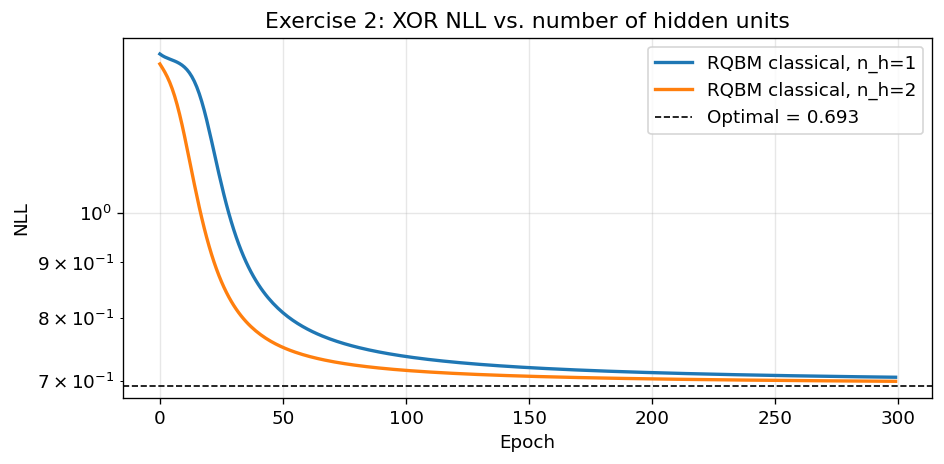

In [13]:
# ── Exercise 2: nh=1 vs nh=2 on XOR ──────────────────────────────
results = {}
for nh_ex in [1, 2]:
    np.random.seed(21)
    az_e = np.random.randn(2)*0.15; bz_e = np.random.randn(nh_ex)*0.15
    W_e  = np.random.randn(2,nh_ex)*0.15; ax_e = np.zeros(2); bx_e = np.zeros(nh_ex)
    hist_e = []
    for epoch in range(300):
        g_az,g_bz,g_W,g_ax,g_bx = qbm_gradient(
            az_e,bz_e,W_e,ax_e,bx_e,xor_target,2,nh_ex,BETA)
        az_e-=0.15*g_az; bz_e-=0.15*g_bz; W_e-=0.15*g_W
        hist_e.append(qbm_nll(az_e,bz_e,W_e,ax_e,bx_e,xor_target,2,nh_ex,BETA))
    H_e = qbm_hamiltonian(az_e,bz_e,W_e,ax_e,bx_e,2,nh_ex)
    p_e,_ = visible_probs(gibbs_state(H_e,BETA),2,nh_ex)
    results[nh_ex] = (hist_e, p_e)
    print(f"  n_h={nh_ex}: final NLL={hist_e[-1]:.4f}  p(v)={p_e.round(3)}")

fig2, ax2 = plt.subplots(figsize=(8, 4))
for nh_ex, (hist_e, _) in results.items():
    ax2.semilogy(hist_e, lw=2, label=f'RQBM classical, n_h={nh_ex}')
ax2.axhline(OPTIMAL, ls='--', c='k', lw=1, label=f'Optimal = {OPTIMAL:.3f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('NLL')
ax2.set_title('Exercise 2: XOR NLL vs. number of hidden units')
ax2.legend(); plt.tight_layout(); plt.show()


### Exercise 3: Increasing beta (lower temperature)


In [14]:
# ── Exercise 3: Effect of beta on the XOR model ───────────────────
beta_vals_ex = [0.5, 1.0, 2.0, 5.0]
print("Effect of beta (inverse temperature) on final XOR NLL:")
print(f"{'beta':>8}  {'NLL':>8}  {'p(00)':>8}  {'p(11)':>8}")
for beta_e in beta_vals_ex:
    np.random.seed(13)
    az_e = np.random.randn(nv)*0.1; bz_e = np.random.randn(nh)*0.1
    W_e  = np.random.randn(nv,nh)*0.1; ax_e = np.zeros(nv); bx_e = np.zeros(nh)
    for epoch in range(300):
        g=qbm_gradient(az_e,bz_e,W_e,ax_e,bx_e,xor_target,nv,nh,beta_e)
        az_e-=0.15*g[0]; bz_e-=0.15*g[1]; W_e-=0.15*g[2]
    nll_e = qbm_nll(az_e,bz_e,W_e,ax_e,bx_e,xor_target,nv,nh,beta_e)
    H_e   = qbm_hamiltonian(az_e,bz_e,W_e,ax_e,bx_e,nv,nh)
    p_e,_ = visible_probs(gibbs_state(H_e,beta_e),nv,nh)
    print(f"{beta_e:>8.1f}  {nll_e:>8.4f}  {p_e[0]:>8.3f}  {p_e[3]:>8.3f}")


Effect of beta (inverse temperature) on final XOR NLL:
    beta       NLL     p(00)     p(11)
     0.5    0.7265     0.484     0.484
     1.0    0.6992     0.497     0.497
     2.0    0.9733     0.173     0.825
     5.0    9.3508     1.000     0.000


---
## 13  Summary

### Key concepts implemented

| Concept | Formula | Notebook section |
|---|---|---|
| Gibbs state | $\rho = e^{-\beta H}/Z$ | §3 |
| Visible marginal | $p(\mathbf{v}) = \langle\mathbf{v}|\mathrm{Tr}_h[\rho]|\mathbf{v}\rangle$ | §3 |
| QBM Hamiltonian | $H = -\sum a_i^z Z_i - \sum W_{ij}Z_iZ_j - \sum a_i^x X_i + \cdots$ | §5 |
| NLL gradient (FD) | $\partial_{\theta}\mathrm{NLL}\approx[\mathrm{NLL}(\theta+h)-\mathrm{NLL}(\theta-h)]/2h$ | §5 |
| Thermofield double | $|\mathrm{TFD}\rangle=Z^{-1/2}\sum_k e^{-\beta\epsilon_k/2}|\epsilon_k\rangle_S|\epsilon_k\rangle_A$ | §9 |
| Free energy | $\mathcal{F}(\rho,H)=\mathrm{Tr}[H\rho]-\beta^{-1}S_{\rm vN}(\rho)$ | §10 |

### XOR benchmark results

The benchmark shows that all three models (classical RBM, RQBM classical mode,
RQBM quantum mode) can learn XOR with $n_h=2$ hidden units. The quantum mode
can reach slightly lower NLL because the transverse fields allow the model to
explore states with off-diagonal coherences in the density matrix — but the
advantage depends sensitively on the Hamiltonian structure and initialisation.

### References

1. M. H. Amin et al., *Quantum Boltzmann machine*, Phys. Rev. X **8**, 021050 (2018).
2. C. Zoufal et al., *Variational quantum Boltzmann machines*, Quantum Mach. Intell. **3**, 7 (2021).
3. D. Zhu et al., *Generation of thermofield double states*, PNAS **117**, 25402 (2020).
4. J. Stokes et al., *Quantum natural gradient*, Quantum **4**, 269 (2020).
